# Excitonic coupling from Coulomb-matrix kernels

The task is to predict the excitonic coupling energy of a molecule pair (A, B) with a kernel model, either Kernel Ridge Regression or Gaussian Process Regression, from Coulomb-matrix representations of the two geometries, and to characterise the result with a learning curve.

`BiMolData/` holds four files: `Coord_A.xyz` and `Coord_B.xyz` with 200 geometries each, `CouplingEnergies.csv` with the coupling energy of every (A, B) pair, and `Coord_supermol.xyz` with the 200x200 pairs treated as single molecules.

In [1]:
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.io import read as ase_read

DATA = Path("BiMolData")

## Geometries

The xyz files concatenate one block per geometry: an atom count, a comment line, then that many `element x y z` rows. `ase` reads the same file and is used to check the parser.

In [2]:
def parse_xyz(path):
    molecules = []
    lines = Path(path).read_text().splitlines()
    i = 0
    while i < len(lines):
        n = int(lines[i].strip())
        block = lines[i + 2 : i + 2 + n]
        elements = [row.split()[0] for row in block]
        coords = np.array([[float(v) for v in row.split()[1:4]] for row in block])
        molecules.append((elements, coords))
        i += 2 + n
    return molecules


mols_A = parse_xyz(DATA / "Coord_A.xyz")
mols_B = parse_xyz(DATA / "Coord_B.xyz")

ase_A = ase_read(str(DATA / "Coord_A.xyz"), index=":")
assert len(ase_A) == len(mols_A)
assert np.allclose(ase_A[0].get_positions(), mols_A[0][1])

In [3]:
def report(name, mols):
    counts = [len(elements) for elements, _ in mols]
    assert len(set(counts)) == 1
    assert all(elements == mols[0][0] for elements, _ in mols)
    composition = dict(collections.Counter(mols[0][0]))
    print(f"{name}: {len(mols)} molecules, {counts[0]} atoms each")
    print(f"  elements: {sorted(composition)}")
    print(f"  composition: {composition}")


report("A", mols_A)
report("B", mols_B)

A: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}
B: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}


Both sets are 200 molecules of 15 atoms, composition C6H5NO3, and the assertions above also establish that the atom ordering is identical across every geometry. A Coulomb matrix therefore has the same shape and the same row and column meaning for every molecule, and flattens into a fixed-length feature vector with no padding and no sorting step.

## Coupling energies

In [4]:
df = pd.read_csv(DATA / "CouplingEnergies.csv")

assert len(df) == 40000
assert sorted(df["molA"].unique()) == list(range(200))
assert sorted(df["molB"].unique()) == list(range(200))

print(df.head())
print(df["coupling_energy"].describe())

   molA  molB  coupling_energy
0     0     0       -27.740949
1     0     1        -1.924393
2     0     2       -50.196196
3     0     3       -65.963198
4     0     4       -56.458111
count    40000.000000
mean        -1.294752
std         38.406155
min       -116.838094
25%        -29.864116
50%         -0.738620
75%         25.254135
max        108.832597
Name: coupling_energy, dtype: float64


The couplings are roughly symmetric about zero, with a standard deviation of 38.4 and a range of about ±110. The brief quotes a reference MAE of 0.01 to 0.1, three orders of magnitude below that spread. Either the reference is stated in different units, or the target is simply very learnable and a good kernel model reaches a relative error of order 1e-3. Nothing in the data alone decides between the two, so the question stays open until there is a learning curve to compare against. Errors are reported throughout in the units of the CSV.

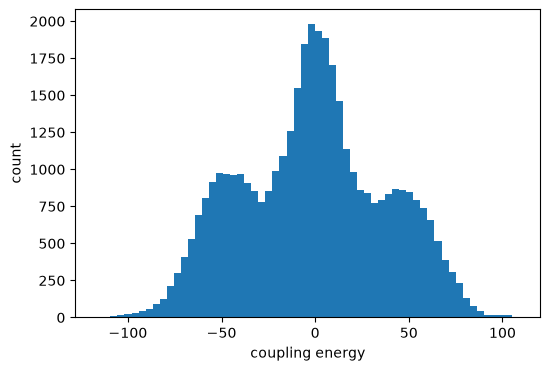

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["coupling_energy"], bins=60)
ax.set_xlabel("coupling energy")
ax.set_ylabel("count")
plt.show()

## Supermolecule geometries

If the pairs had been assembled by placing the two molecules at some relative separation and orientation, that arrangement would itself carry information about the coupling. Comparing supermolecule row `i * 200 + j` against the concatenation of A_i and B_j settles whether it does.

In [6]:
mols_S = parse_xyz(DATA / "Coord_supermol.xyz")
n_A, n_B = len(mols_A[0][0]), len(mols_B[0][0])

assert len(mols_S) == 40000
assert all(len(elements) == n_A + n_B for elements, _ in mols_S)

deviation = 0.0
for i in range(len(mols_A)):
    for j in range(len(mols_B)):
        coords = mols_S[i * len(mols_B) + j][1]
        deviation = max(
            deviation,
            np.abs(coords[:n_A] - mols_A[i][1]).max(),
            np.abs(coords[n_A:] - mols_B[j][1]).max(),
        )

print(f"supermolecules: {len(mols_S)} geometries of {n_A + n_B} atoms")
print(f"max coordinate deviation from concatenated A_i, B_j over all pairs: {deviation:.3g}")

supermolecules: 40000 geometries of 30 atoms
max coordinate deviation from concatenated A_i, B_j over all pairs: 0


Every supermolecule reproduces A_i and B_j exactly, atom for atom, with zero coordinate deviation. Nothing is rotated, translated or displaced when a pair is assembled, so `Coord_supermol.xyz` is a deterministic function of the standalone geometries and holds no information they do not already hold.

That does not make it useless as a representation. A Coulomb matrix built on the supermolecule contains the cross-block Z_i Z_j / |r_i - r_j| between the atoms of A and those of B, an explicit encoding of the pair interaction; reaching the same quantity from the two molecules separately means constructing it by hand. Which of the two to feed the kernel is a modelling decision rather than an information one, and it is the next thing to settle.

## Coulomb-matrix representation

The Coulomb matrix of a geometry is

$$M_{ij} = \begin{cases} \tfrac{1}{2} Z_i^{2.4} & i = j \\[2pt] \dfrac{Z_i Z_j}{\lVert r_i - r_j \rVert} & i \neq j \end{cases}$$

The usual recipe then sorts the rows by norm, or takes the eigenvalue spectrum, to make the descriptor invariant to the order in which atoms happen to be listed. Neither is needed here: the assertions above establish that all 400 monomers carry the same 15 atoms in the same order, so row `k` already means the same atom in every geometry. Sorting would only destroy that correspondence.

The diagonal is worth a second look. It depends on nothing but the element identities, and those are fixed by the constant composition and ordering, so it is the same 15 numbers for every molecule in the set. It carries no information and is dropped. What remains is the strict upper triangle: 105 numbers per monomer.

In [7]:
Z = {"H": 1, "C": 6, "N": 7, "O": 8}


def coulomb_matrix(elements, coords):
    z = np.array([Z[e] for e in elements], dtype=float)
    d = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    M = z[:, None] * z[None, :] / d
    np.fill_diagonal(M, 0.5 * z**2.4)
    return M


def descriptors(mols):
    iu = np.triu_indices(len(mols[0][0]), k=1)
    return np.array([coulomb_matrix(elements, coords)[iu] for elements, coords in mols])


diagonals = np.array([np.diag(coulomb_matrix(e, c)) for e, c in mols_A + mols_B])
assert np.allclose(diagonals, diagonals[0])

X_A = descriptors(mols_A)
X_B = descriptors(mols_B)

print(f"descriptor: {X_A.shape[1]} off-diagonal entries per monomer")
print(f"X_A {X_A.shape}, X_B {X_B.shape}")
print(f"discarded diagonal (identical in every monomer): {diagonals[0].round(2)}")

descriptor: 105 off-diagonal entries per monomer
X_A (200, 105), X_B (200, 105)
discarded diagonal (identical in every monomer): [53.36 73.52 73.52 36.86 36.86 36.86 36.86 36.86 36.86 73.52  0.5   0.5
  0.5   0.5   0.5 ]


Cross-checked against `dscribe`, which implements the same definition, with `permutation="none"` to match the unsorted convention used here.

In [8]:
from ase import Atoms
from dscribe.descriptors import CoulombMatrix

dscribe_cm = CoulombMatrix(n_atoms_max=len(mols_A[0][0]), permutation="none")
for elements, coords in [mols_A[0], mols_B[0], mols_A[137]]:
    reference = dscribe_cm.create(Atoms(symbols=elements, positions=coords)).reshape(15, 15)
    assert np.allclose(reference, coulomb_matrix(elements, coords))